# Detección de crisis epilépticas — extensión a 14 ratas### PSIB 2026 Q1 · Parte 2 · Grupo 5Réplica del pipeline validado en 6 ratas, extendido a **14 ratas** (las 15 de lalista menos C13). Usa las decisiones finales, sin los experimentos intermedios:- **Detector:** CWT `mexh` · z>18 MADs · ≥2 canales · ≥5 s sostenidos · margen 2 s- **Etiquetas:** interictal [0, onset−30] · ictal [onset+10, onset+30]- **ML:** features WPD (db4, nivel 6) → normalización por rata → LORO- **Modelos:** Random Forest y MLP (64,32)**Diferencia con la versión de 6 ratas:** no se corre el control de especificidaddel detector (ya demostrado 0/12 falsos positivos). El `non` se descarga igualporque es **imprescindible para normalizar** las features del ML — sin eso, elmodelo aprende la identidad del animal y LORO se cae (AUC 0.64 vs 0.96).---### ⚠ Cosas a vigilar al correr1. **Ratas que se saltean** (celda 2): si el nombre en el dataset difiere, avisa.2. **B6 debe dar ictal9/ictal10** — control conocido.3. **Onsets censurados** (celda 6): ictales que arrancan en el borde quedan sin   etiqueta. De 28 ictales van a salir menos fragmentos etiquetados.

## 1 · Setup

In [ ]:
# ══ 1 · SETUP ════════════════════════════════════════════════════════════
!pip install dandi pynwb PyWavelets -q

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal as sp_sig
from scipy.ndimage import uniform_filter1d
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

BASE = '/content/drive/MyDrive/psib_14ratas'      # carpeta nueva, no pisa la de 6
for sub in ('senales', 'senales_non', 'cache'):
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)

LABELS = ['R_SUB','R_DG','R_CA1','R_CA3','R_AMD','R_ANT',
          'L_SUB','L_DG','L_CA1','L_CA3','L_AMD','L_ANT']
FS_ORIG, FS = 1000, 500
FREQS = np.logspace(np.log10(2), np.log10(200), 32)

# ── parámetros FINALES del detector (validados en 6 ratas) ──────────────
WAVELET   = 'mexh'
K_MAD     = 18
MIN_CAN   = 2
DUR_S     = 5.0
SUAV_S    = 0.25
MARGEN_S  = 2.0
BANDAS = {'delta':(1,4), 'theta_alpha':(4,12), 'beta':(13,30),
          'gamma':(30,80), 'alta':(80,200)}

# ── 15 de Lu menos C13 = 14 ─────────────────────────────────────────────
RATAS = ['RatB6','RatC3','RatC16','RatD17','RatE2','RatE5',
         'Rat4','Rat7','Rat8','RatR2','RatR3','RatR5','RatR6','RatZ11']
N_ICTALES = 2
DANDISET_ID, VER = "001044", "0.240905.0159"

print(f'{WAVELET} · z>{K_MAD} · ≥{MIN_CAN} canales · ≥{DUR_S}s · margen {MARGEN_S}s')
print(f'{len(RATAS)} ratas · {N_ICTALES} ictales c/u')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.3/362.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/1

## 2 · Selección de archivos (no descarga aún)Solo lista qué se va a bajar, para verificar antes de gastar la descarga.Criterio: los 2 ictales más recientes (late) + el `non` de fecha más cercana.

In [ ]:
# ══ 2 · PLAN DE DESCARGA (solo mira) ═════════════════════════════════════
print(f'Buscando archivos de {len(RATAS)} ratas...\n')
PLAN = {}
with DandiAPIClient() as cl:
    ds = cl.get_dandiset(DANDISET_ID, VER)
    assets = list(ds.get_assets())
    for rata in RATAS:
        ict = sorted([(a.path.split('/')[-1].split('ses-')[1][:8],
                       a.path.split('/')[-1], a) for a in assets
                      if f'{rata}_' in a.path.split('/')[-1] and '-ictal' in a.path
                      and '-small' not in a.path])
        non = sorted([(a.path.split('/')[-1].split('ses-')[1][:8],
                       a.path.split('/')[-1], a) for a in assets
                      if f'{rata}_' in a.path.split('/')[-1] and '-non' in a.path])
        if len(ict) < N_ICTALES or not non:
            print(f'  ✗ {rata}: {len(ict)} ictales, {len(non)} non → SE SALTEA')
            continue
        sel_ict = ict[-N_ICTALES:]
        f_obj = int(sel_ict[0][0])
        sel_non = min(non, key=lambda x: abs(int(x[0])-f_obj))
        PLAN[rata] = {'ictales': sel_ict, 'non': sel_non}

mb = 0
print(f'\n{"rata":<8s}{"ictal 1":>26s}{"ictal 2":>26s}{"non":>22s}')
print('-'*82)
for rata, p in PLAN.items():
    i1, i2 = p['ictales']
    mb += sum(a.size for _,_,a in p['ictales']) + p['non'][2].size
    print(f'{rata:<8s}{i1[1].split("ses-")[1][:18]:>26s}'
          f'{i2[1].split("ses-")[1][:18]:>26s}{p["non"][1].split("ses-")[1][:14]:>22s}')
print(f'\n  {len(PLAN)} ratas listas · {len(PLAN)*N_ICTALES} ictales + {len(PLAN)} non · ~{mb/1e6:.0f} MB')
print('  ⚠ Verificá que RatB6 dé ictal9 e ictal10.')

Buscando archivos de 14 ratas...

  ✗ Rat4: 0 ictales, 0 non → SE SALTEA
  ✗ Rat7: 0 ictales, 0 non → SE SALTEA
  ✗ Rat8: 0 ictales, 0 non → SE SALTEA

rata                       ictal 1                   ictal 2                   non
----------------------------------------------------------------------------------
RatB6           20230724-ictal9_ec        20230725-ictal10_e        20230723-non_e
RatC3           20231023-ictal23_e        20231024-ictal23_e        20231020-non_e
RatC16          20231030-ictal10_e        20231031-ictal1_ec        20231101-non_e
RatD17          20240104-ictal9_ec        20240105-ictal15_e        20240102-non_e
RatE2           20190703-ictal1_ec        20190707-ictal2_ec        20190705-non_e
RatE5           20190531-ictal3_ec        20190601-ictal6_ec        20190526-non_e
RatR2           20220429-ictal12_e        20220430-ictal11_e        20220425-non_e
RatR3           20220319-ictal30_e        20220320-ictal29_e        20220316-non_e
RatR5           20

## 3 · Descarga y decimado a 500 HzBaja los archivos del PLAN, decima 1000→500 Hz, guarda en Drive.Se cachea: si la sesión se corta, volvé a correr y retoma lo que falta.Preprocesamiento: **ninguno** (el paper ya aplicó notch y pasabanda).

In [ ]:
# ══ 3 · DESCARGA + DECIMADO ══════════════════════════════════════════════
def decimar(raw):
    n = len(sp_sig.decimate(raw[:,0], FS_ORIG//FS, ftype='fir', zero_phase=True))
    o = np.zeros((n,12), dtype=np.float32)
    for c in range(12):
        o[:,c] = sp_sig.decimate(raw[:,c], FS_ORIG//FS, ftype='fir', zero_phase=True)
    return o

with DandiAPIClient() as cl:
    ds = cl.get_dandiset(DANDISET_ID, VER)
    for rata, p in PLAN.items():
        # ictales → primera serie de cada archivo
        for _, nom, a in p['ictales']:
            tmp = f'/content/{nom}'
            if not os.path.exists(tmp): a.download(tmp)
            io = NWBHDF5IO(tmp, mode='r', load_namespaces=True); nwb = io.read()
            s = sorted(nwb.acquisition.keys())[0]
            dst = f'{BASE}/senales/{s}.npz'
            if not os.path.exists(dst):
                np.savez_compressed(dst, sig=decimar(nwb.acquisition[s].data[:]), rata=rata)
            io.close(); os.remove(tmp)
            print(f'  ✓ {rata:8s} ictal {s}')
        # non → las 2 series
        _, nom, a = p['non']
        tmp = f'/content/{nom}'
        if not os.path.exists(tmp): a.download(tmp)
        io = NWBHDF5IO(tmp, mode='r', load_namespaces=True); nwb = io.read()
        for s in sorted(nwb.acquisition.keys()):
            dst = f'{BASE}/senales_non/{s}.npz'
            if not os.path.exists(dst):
                np.savez_compressed(dst, sig=decimar(nwb.acquisition[s].data[:]), rata=rata)
        io.close(); os.remove(tmp)
        print(f'  ✓ {rata:8s} non ({len(nwb.acquisition)} series)')

print('\nDescarga completa.')

INFO:dandi:Asset b62a0af4-03a8-46d2-a8af-c803d9bb5f86 (195189494 bytes in 24 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/b62a0af4-03a8-46d2-a8af-c803d9bb5f86/download/


  ✓ RatB6    ictal B6_2023_7_24-ictal1


INFO:dandi:Asset 59c37d97-83d9-45ea-9dec-5835b6d1243a (223151536 bytes in 27 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/59c37d97-83d9-45ea-9dec-5835b6d1243a/download/


  ✓ RatB6    ictal B6_2023_7_25-ictal1


INFO:dandi:Asset fa897829-d39a-4ce6-88b4-6f4af4bc3220 (44332201 bytes in 6 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/fa897829-d39a-4ce6-88b4-6f4af4bc3220/download/


...

  ✓ RatZ11   ictal Z11_2021_11_19-ictal1


INFO:dandi:Asset 2d96efeb-3aaa-4bbe-89fc-f6413c454a75 (21561159 bytes in 3 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/2d96efeb-3aaa-4bbe-89fc-f6413c454a75/download/


  ✓ RatZ11   ictal Z11_2021_11_20-ictal1


INFO:dandi:Asset 70203f54-060b-4118-bdc9-8bcb14145979 (40837929 bytes in 5 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/70203f54-060b-4118-bdc9-8bcb14145979/download/


  ✓ RatZ11   non (2 series)

Descarga completa.


## 4 · Cargar señales desde disco

In [ ]:
# ══ 4 · CARGAR ═══════════════════════════════════════════════════════════
def cargar(carpeta):
    D = {}
    for f in sorted(glob.glob(f'{BASE}/{carpeta}/*.npz')):
        fid = os.path.basename(f)[:-4]
        d = np.load(f, allow_pickle=True)
        D[fid] = {'sig': d['sig'], 'rata': str(d['rata'])}
    return D

FRAG, NONS = cargar('senales'), cargar('senales_non')
ratas = sorted({d['rata'] for d in FRAG.values()})
print(f'{len(FRAG)} ictales · {len(NONS)} non · {len(ratas)} ratas\n')
for fid in sorted(FRAG, key=lambda x: FRAG[x]['rata']):
    print(f'  {FRAG[fid]["rata"]:8s} {fid:26s} {FRAG[fid]["sig"].shape}')

22 ictales · 22 non · 11 ratas

  RatB6    B6_2023_7_24-ictal1        (300000, 12)
  RatB6    B6_2023_7_25-ictal1        (300000, 12)
  RatC16   C16_2023_10_30-ictal1      (300000, 12)
  RatC16   C16_2023_10_31-ictal1      (300000, 12)
  RatC3    C3_2023_10_23-ictal1       (300000, 12)
  RatC3    C3_2023_10_24-ictal1       (300000, 12)
  RatD17   D17_2024_1_4-ictal1        (300000, 12)
  RatD17   D17_2024_1_5-ictal1        (300000, 12)
  RatE2    E2_2019_7_3-ictal1         (300000, 12)
  RatE2    E2_2019_7_7-ictal1         (300000, 12)
  RatE5    E5_2019_5_31-ictal1        (300000, 12)
  RatE5    E5_2019_6_1-ictal1         (300000, 12)
  RatR2    R2_2022_4_29-ictal1        (300000, 12)
  RatR2    R2_2022_4_30-ictal1        (300000, 12)
  RatR3    R3_2022_3_19-ictal1        (300000, 12)
  RatR3    R3_2022_3_20-ictal1        (300000, 12)
  RatR5    R5_2022_4_22-ictal1        (300000, 12)
  RatR5    R5_2022_4_23-ictal1        (300000, 12)
  RatR6    R6_2022_4_27-ictal1        (300000, 12)

## 5 · Detector: CWT mexh → z(t) → onsetMotor final validado. Calcula `z(t)` de los 12 canales de cada fragmento(ictales y non). Se cachea en disco (~15 min la primera vez con 42 fragmentos).

In [ ]:
# ══ 5 · MOTOR + z(t) ═════════════════════════════════════════════════════
def cwt_potencia(x):
    fc = pywt.central_frequency(WAVELET)
    coef, _ = pywt.cwt(x, fc*FS/FREQS, WAVELET, sampling_period=1/FS, method='fft')
    return np.abs(coef)**2

def z_agnostico(pot):
    n = max(1, int(SUAV_S*FS)); zs = []
    for (f0,f1) in BANDAS.values():
        m = (FREQS>=f0) & (FREQS<=f1)
        if m.sum()==0: continue
        w = uniform_filter1d(pot[m,:].mean(axis=0), size=n)
        med = np.median(w); mad = np.median(np.abs(w-med))+1e-12
        zs.append((w-med)/mad)
    return np.max(np.vstack(zs), axis=0)

def z_de(fid, sig):
    f = f'{BASE}/cache/{fid}__{WAVELET}.npz'
    if os.path.exists(f): return np.load(f)['z']
    zs = np.vstack([z_agnostico(cwt_potencia(sig[:,c])) for c in range(12)])
    np.savez_compressed(f, z=zs.astype(np.float32))
    return zs

print('Calculando z (ictales)...')
Z_ICT = {}
for k, (fid, d) in enumerate(FRAG.items()):
    Z_ICT[fid] = z_de(fid, d['sig'])
    if (k+1) % 5 == 0: print(f'  {k+1}/{len(FRAG)}')
print('Calculando z (non)...')
Z_NON = {}
for k, (fid, d) in enumerate(NONS.items()):
    Z_NON[fid] = z_de(fid, d['sig'])
    if (k+1) % 5 == 0: print(f'  {k+1}/{len(NONS)}')
print(f'  ✓ {len(Z_ICT)} ictales · {len(Z_NON)} non')

Calculando z (ictales)...
  5/22
  10/22
  15/22
  20/22
Calculando z (non)...
  5/22
  10/22
  15/22
  20/22
  ✓ 22 ictales · 22 non


## 6 · Detección de onset + generación de etiquetasCriterio: primer instante con ≥2 canales sobre z=18 sostenido 5 s, margen 2 s.Etiquetas por fragmento:- **interictal** = [0, onset−30]- **ictal** = [onset+10, onset+30]  (el paper garantiza crisis >30 s)- **onset censurado** (≤ margen) → sin etiqueta, no aporta al ML- **non** = interictal completo (clase 0, sin heurística)

In [ ]:
# ══ 6 · ONSET + ETIQUETAS ════════════════════════════════════════════════
def detectar(zs, k=K_MAD, min_can=MIN_CAN, dur_s=DUR_S, margen=MARGEN_S):
    act = (zs > k).sum(axis=0)
    ok = act >= min_can
    n_m = int(margen*FS); ok[:n_m]=False; ok[-n_m:]=False
    d = np.diff(ok.astype(int))
    ini = np.where(d==1)[0]+1; fin = np.where(d==-1)[0]+1
    if ok[0]: ini = np.r_[0, ini]
    if ok[-1]: fin = np.r_[fin, len(ok)]
    for i,f in zip(ini,fin):
        if f-i >= int(dur_s*FS):
            return {'onset': i/FS, 'n_max': int(act[i:f].max()),
                    'censurado': i/FS <= margen+0.1}
    return None

MARGEN_PRE, MARGEN_POST, DUR_ICTAL = 30.0, 10.0, 30.0
etiquetas = {}
print(f'{"fragmento":<26s}{"rata":>8s}{"onset":>9s}{"estado":>16s}')
print('-'*60)
n_ok = n_cens = n_sin = 0
for fid in sorted(FRAG, key=lambda x: FRAG[x]['rata']):
    r = detectar(Z_ICT[fid])
    if r is None:
        print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{"—":>9s}{"sin detección":>16s}'); n_sin+=1; continue
    if r['censurado']:
        print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{r["onset"]:>7.1f}s{"censurado":>16s}'); n_cens+=1; continue
    T = FRAG[fid]['sig'].shape[0]/FS
    o = r['onset']
    etiquetas[fid] = {'rata': FRAG[fid]['rata'], 'onset': o,
                      'interictal': (0.0, max(0.0, o-MARGEN_PRE)),
                      'ictal': (o+MARGEN_POST, min(T, o+DUR_ICTAL))}
    print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{o:>7.1f}s{"✓ etiquetado":>16s}'); n_ok+=1

# non → interictal completo
for fid, d in NONS.items():
    etiquetas[fid] = {'rata': d['rata'], 'onset': None,
                      'interictal': (0.0, d['sig'].shape[0]/FS), 'ictal': None}

np.save(f'{BASE}/etiquetas.npy', etiquetas)
print(f'\n  ictales etiquetados: {n_ok} · censurados: {n_cens} · sin detección: {n_sin}')
print(f'  non (clase 0): {len(NONS)}')
print(f'  ✓ etiquetas.npy · {len(etiquetas)} fragmentos totales')

fragmento                     rata    onset          estado
------------------------------------------------------------
B6_2023_7_24-ictal1          RatB6  317.6s    ✓ etiquetado
B6_2023_7_25-ictal1          RatB6  298.2s    ✓ etiquetado
C16_2023_10_30-ictal1       RatC16  283.1s    ✓ etiquetado
C16_2023_10_31-ictal1       RatC16  272.7s    ✓ etiquetado
C3_2023_10_23-ictal1         RatC3  325.9s    ✓ etiquetado
C3_2023_10_24-ictal1         RatC3  349.1s    ✓ etiquetado
D17_2024_1_4-ictal1         RatD17  305.1s    ✓ etiquetado
D17_2024_1_5-ictal1         RatD17  273.8s    ✓ etiquetado
E2_2019_7_3-ictal1           RatE2  334.6s    ✓ etiquetado
E2_2019_7_7-ictal1           RatE2  274.6s    ✓ etiquetado
E5_2019_5_31-ictal1          RatE5  364.7s    ✓ etiquetado
E5_2019_6_1-ictal1           RatE5  343.3s    ✓ etiquetado
R2_2022_4_29-ictal1          RatR2    2.0s       censurado
R2_2022_4_30-ictal1          RatR2  273.4s    ✓ etiquetado
R3_2022_3_19-ictal1          RatR3        —   sin det

## 7 · Ventaneo (2 s, paso 1 s) — hereda las etiquetas

In [ ]:
# ══ 7 · VENTANEO ═════════════════════════════════════════════════════════
SIG = {}
for fid in FRAG: SIG[fid] = FRAG[fid]['sig']
for fid in NONS: SIG[fid] = NONS[fid]['sig']

WIN_S, STEP_S = 2.0, 1.0
VENTANAS = []
for fid, e in etiquetas.items():
    T = SIG[fid].shape[0]/FS; t = 0.0
    while t+WIN_S <= T:
        tf = t+WIN_S; clase = None
        if e['interictal'][0] <= t and tf <= e['interictal'][1]: clase = 0
        elif e['ictal'] and e['ictal'][0] <= t and tf <= e['ictal'][1]: clase = 1
        if clase is not None: VENTANAS.append((fid, e['rata'], t, clase))
        t += STEP_S

n0 = sum(1 for v in VENTANAS if v[3]==0); n1 = sum(1 for v in VENTANAS if v[3]==1)
print(f'{len(VENTANAS)} ventanas · interictal {n0} · ictal {n1} · desbalance {n0/max(n1,1):.0f}:1')
print(f'\n{"rata":<9s}{"interictal":>12s}{"ictal":>8s}')
print('-'*30)
for r in ratas:
    v=[x for x in VENTANAS if x[1]==r]
    print(f'{r:<9s}{sum(1 for x in v if x[3]==0):>12d}{sum(1 for x in v if x[3]==1):>8d}')

18403 ventanas · interictal 18061 · ictal 342 · desbalance 53:1

rata       interictal   ictal
------------------------------
RatB6            1751      36
RatC16           1691      36
RatC3            1810      36
RatD17           1714      36
RatE2            1744      36
RatE5            1843      36
RatR2            1440      18
RatR3            1198       0
RatR5            1699      36
RatR6            1682      36
RatZ11           1489      36


## 8 · Features con WPDWPD (db4, nivel 6) → 5 energías relativas por banda + entropía = 6 por canal× 12 = 72 features. Energía **relativa** (no absoluta) para no codificar laamplitud del electrodo. Se cachea en disco.

In [ ]:
# ══ 8 · FEATURES WPD ═════════════════════════════════════════════════════
WAVELET_F, NIVEL = 'db4', 6
N_NODOS = 2**NIVEL; BW = (FS/2)/N_NODOS
NODOS = {nom: [i for i in range(N_NODOS) if (i*BW < f1) and ((i+1)*BW > f0)]
         for nom,(f0,f1) in BANDAS.items()}
NOMBRES = [f'{b}_{ch}' for ch in LABELS for b in list(BANDAS)+['entropia']]

def features_canal(x):
    wp = pywt.WaveletPacket(x, WAVELET_F, maxlevel=NIVEL)
    nodos = wp.get_level(NIVEL, 'freq')          # 'freq' NO 'natural'
    E = np.array([np.sum(n.data**2) for n in nodos])
    Eb = np.array([E[NODOS[b]].sum() for b in BANDAS])
    rel = Eb/(Eb.sum()+1e-12)
    ent = -np.sum(rel*np.log2(rel+1e-12))
    return np.r_[rel, ent]

fcache = f'{BASE}/features_wpd.npz'
if os.path.exists(fcache):
    d = np.load(fcache, allow_pickle=True)
    X, y, grupo, origen = d['X'], d['y'], d['grupo'], d['origen']
    print(f'Features cargadas de cache: {X.shape}')
else:
    print(f'Calculando features de {len(VENTANAS)} ventanas...')
    X, y, grupo, origen = [], [], [], []
    for k,(fid,rata,t0,clase) in enumerate(VENTANAS):
        if k%3000==0: print(f'  {k}/{len(VENTANAS)}')
        i0 = int(t0*FS); seg = SIG[fid][i0:i0+int(WIN_S*FS), :]
        X.append(np.concatenate([features_canal(seg[:,c]) for c in range(12)]))
        y.append(clase); grupo.append(rata); origen.append(fid)
    X=np.array(X); y=np.array(y); grupo=np.array(grupo); origen=np.array(origen)
    np.savez_compressed(fcache, X=X, y=y, grupo=grupo, origen=origen, nombres=NOMBRES)
    print('  ✓ features_wpd.npz')

print(f'\nX: {X.shape} · y: {np.sum(y==0)} interictal / {np.sum(y==1)} ictal')
print(f'NaN: {np.isnan(X).sum()} · Inf: {np.isinf(X).sum()}')

Calculando features de 18403 ventanas...
  0/18403
  3000/18403
  6000/18403
  9000/18403
  12000/18403
  15000/18403
  18000/18403
  ✓ features_wpd.npz

X: (18403, 72) · y: 18061 interictal / 342 ictal
NaN: 0 · Inf: 0


## 9 · Normalización por rata (contra su interictal)Cada rata se estandariza con la media/desvío de **sus propias ventanasinterictales**. Cancela la huella del animal sin fuga (el estadístico de larata i sale solo de la rata i). Es lo que llevó el AUC de 0.64 a 0.96.

In [ ]:
# ══ 9 · NORMALIZACIÓN ════════════════════════════════════════════════════
XN = np.zeros_like(X, dtype=np.float64)
print(f'{"rata":<9s}{"n interictal":>14s}')
print('-'*24)
for r in ratas:
    m_r = grupo==r; m_ref = m_r & (y==0)
    if m_ref.sum() < 10:
        XN[m_r] = X[m_r]; print(f'{r:<9s}{m_ref.sum():>14d}  (sin ref, sin normalizar)'); continue
    mu = X[m_ref].mean(0); sd = X[m_ref].std(0); sd[sd<1e-8]=1.0
    XN[m_r] = (X[m_r]-mu)/sd
    print(f'{r:<9s}{m_ref.sum():>14d}')
print(f'\nXN: {XN.shape} · NaN: {np.isnan(XN).sum()} · Inf: {np.isinf(XN).sum()}')

rata       n interictal
------------------------
RatB6              1751
RatC16             1691
RatC3              1810
RatD17             1714
RatE2              1744
RatE5              1843
RatR2              1440
RatR3              1198
RatR5              1699
RatR6              1682
RatZ11             1489

XN: (18403, 72) · NaN: 0 · Inf: 0


## 10 · Los dos modelos con LORORandom Forest y MLP (64,32), mismo esquema:- **LORO**: entrena con 13 ratas, predice la 14ª, rota.- **Corte** elegido por CV interna agrupada (GroupKFold) — sin tocar el test.- Métricas: sensibilidad, especificidad, AUC (NO accuracy, por el desbalance).

In [ ]:
# ══ 10 · LORO — RANDOM FOREST + MLP ══════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

N_FOLD_INT = 3
def umbral_youden(yt, p):
    fpr, tpr, thr = roc_curve(yt, p); return float(thr[np.argmax(tpr-fpr)])

def evaluar_loro(construir, Xd, yd, gd, nombre):
    logo = LeaveOneGroupOut()
    filas, prob = [], np.full(len(yd), np.nan)
    print(f'\n{nombre}')
    print(f'{"rata test":<10s}{"corte":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
    print('-'*43)
    for tr, te in logo.split(Xd, yd, gd):
        rt = gd[te][0]
        n_gr = len(np.unique(gd[tr]))
        cv = GroupKFold(n_splits=min(N_FOLD_INT, n_gr))
        p_int = cross_val_predict(construir(), Xd[tr], yd[tr], groups=gd[tr],
                                  cv=cv, method='predict_proba', n_jobs=-1)[:,1]
        corte = umbral_youden(yd[tr], p_int)
        mod = construir().fit(Xd[tr], yd[tr])
        p_te = mod.predict_proba(Xd[te])[:,1]; prob[te] = p_te
        pred = (p_te>=corte).astype(int)
        tn,fp,fn,tp = confusion_matrix(yd[te], pred, labels=[0,1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) else np.nan
        esp  = tn/(tn+fp) if (tn+fp) else np.nan
        auc  = roc_auc_score(yd[te], p_te) if len(np.unique(yd[te]))>1 else np.nan
        filas.append({'rata':rt,'sens':sens,'espec':esp,'auc':auc})
        print(f'{rt:<10s}{corte:>9.3f}{sens:>8.3f}{esp:>8.3f}{auc:>8.3f}')
    ms=np.nanmean([f['sens'] for f in filas]); me=np.nanmean([f['espec'] for f in filas])
    ma=np.nanmean([f['auc'] for f in filas])
    print('-'*43); print(f'{"MEDIA":<10s}{"":>9s}{ms:>8.3f}{me:>8.3f}{ma:>8.3f}')
    return {'nombre':nombre,'filas':filas,'prob':prob,'sens':ms,'espec':me,'auc':ma}

def modelo_rf():
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  min_samples_leaf=2, random_state=0, n_jobs=-1)
def modelo_mlp():
    return Pipeline([('sc',StandardScaler()),
                     ('nn',MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                          solver='adam', alpha=1e-3, learning_rate_init=1e-3,
                          max_iter=400, early_stopping=True, n_iter_no_change=15,
                          random_state=0))])

print('='*60); print('MODELO 1 · RANDOM FOREST'); print('='*60)
RES_RF = evaluar_loro(modelo_rf, XN, y, grupo, 'Random Forest')
print('\n'+'='*60); print('MODELO 2 · MLP (64,32)'); print('='*60)
RES_MLP = evaluar_loro(modelo_mlp, XN, y, grupo, 'MLP')

MODELO 1 · RANDOM FOREST

Random Forest
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.026   1.000   0.885   0.992
RatC16        0.029   1.000   0.893   0.998
RatC3         0.023   0.944   0.903   0.976
RatD17        0.023   0.917   0.891   0.967
RatE2         0.029   1.000   0.888   0.998
RatE5         0.027   1.000   0.801   0.935
RatR2         0.029   1.000   0.908   0.981
RatR3         0.027     nan   0.942     nan
RatR5         0.023   0.944   0.961   0.994
RatR6         0.023   1.000   0.925   0.992
RatZ11        0.033   0.722   0.910   0.939
-------------------------------------------
MEDIA                 0.953   0.901   0.977

MODELO 2 · MLP (64,32)

MLP
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.011   0.611   0.988   0.961
RatC16        0.003   0.389   0.957   0.776
RatC3         0.006   0.528   0.952   0.809
RatD17        0.015   0.000   0.933   0.072
RatE2  

## 11 · Comparación final

modelo                 sens    espec      AUC
---------------------------------------------
Random Forest         0.953    0.901    0.977
MLP                   0.453    0.944    0.707


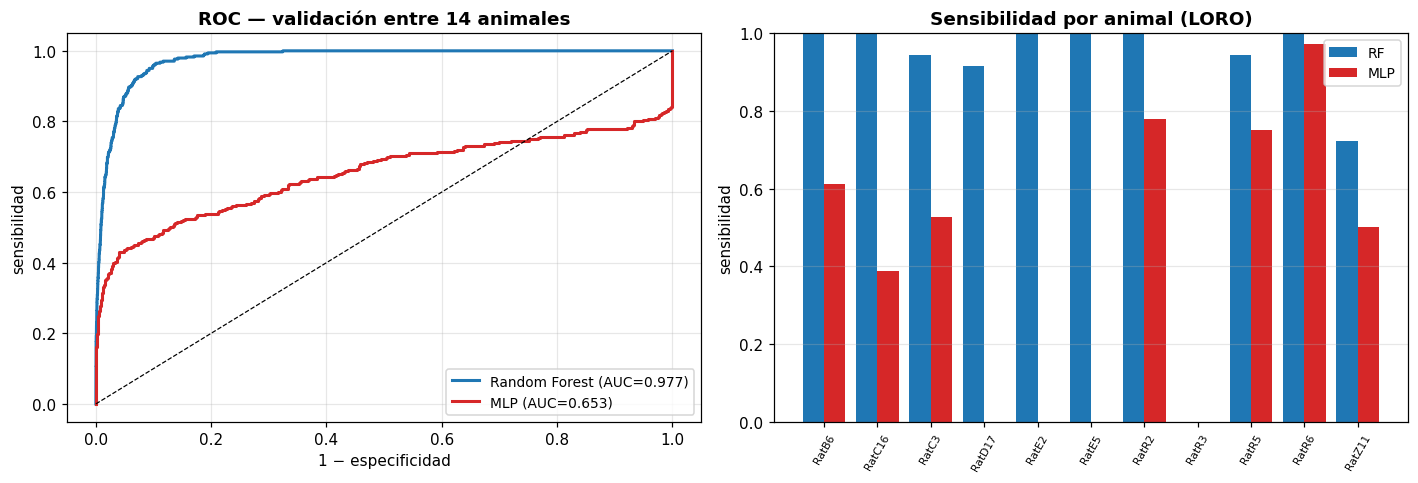


  ✓ resultados.npz guardado en /content/drive/MyDrive/psib_14ratas


In [ ]:
# ══ 11 · COMPARACIÓN ═════════════════════════════════════════════════════
print(f'{"modelo":<18s}{"sens":>9s}{"espec":>9s}{"AUC":>9s}')
print('-'*45)
for R in (RES_RF, RES_MLP):
    print(f'{R["nombre"]:<18s}{R["sens"]:>9.3f}{R["espec"]:>9.3f}{R["auc"]:>9.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for R, col in ((RES_RF,'tab:blue'), (RES_MLP,'tab:red')):
    m = np.isfinite(R['prob'])
    fpr, tpr, _ = roc_curve(y[m], R['prob'][m])
    ax[0].plot(fpr, tpr, color=col, lw=2,
               label=f'{R["nombre"]} (AUC={roc_auc_score(y[m],R["prob"][m]):.3f})')
ax[0].plot([0,1],[0,1],'k--',lw=.8)
ax[0].set_xlabel('1 − especificidad'); ax[0].set_ylabel('sensibilidad')
ax[0].set_title('ROC — validación entre 14 animales', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

x_ = np.arange(len(ratas))
s_rf = [next((f['sens'] for f in RES_RF['filas'] if f['rata']==r), np.nan) for r in ratas]
s_nn = [next((f['sens'] for f in RES_MLP['filas'] if f['rata']==r), np.nan) for r in ratas]
ax[1].bar(x_-.2, s_rf, .4, label='RF', color='tab:blue')
ax[1].bar(x_+.2, s_nn, .4, label='MLP', color='tab:red')
ax[1].set_xticks(x_); ax[1].set_xticklabels(ratas, rotation=60, fontsize=7)
ax[1].set_ylabel('sensibilidad'); ax[1].set_ylim(0,1)
ax[1].set_title('Sensibilidad por animal (LORO)', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

np.savez_compressed(f'{BASE}/resultados.npz',
                    prob_rf=RES_RF['prob'], prob_mlp=RES_MLP['prob'],
                    y=y, grupo=grupo, origen=origen)
print(f'\n  ✓ resultados.npz guardado en {BASE}')